# SSC (Synucleinopathy Cohort Canada) — Data Analysis

This notebook analyzes data extracted from the SSC study, which enrolled patients with Parkinson's Disease and related synucleinopathies.

**Datasets available:**
- `Demographic` — Age, gender, marital status, living situation
- `Clinical` — Diagnosis, weight, vitals
- `Enrollement` — Enrollment site, language, screening info
- `MoCA` — Montreal Cognitive Assessment (cognitive screening)
- `MDS-UPDRS` — Motor & non-motor symptom severity (Parts I–IV)
- `Medication`, `MoCA-1/2`, `MDS-UPDRS-1`, `BDII`, `BAI`, `EHI`, and more

Each dataset shares `Project key` (patient ID) and `Event Name` (visit) as join keys.

## 1. Setup

In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_colwidth', 60)

DATA_DIR = os.path.join(os.getcwd(), 'data')

# Consistent color palette throughout the notebook
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120

print('Data directory:', DATA_DIR)
print('Files found:', os.listdir(DATA_DIR))

Data directory: /Users/manrajsingh/Desktop/SSC/SSC/data
Files found: ['Apathy Evaluation Informant', 'UPDRS 1.2 part 3', 'Fatigue Severity Scale', 'Neuropsychological (CaPRI)', 'MBIC', 'Demographic', 'Parkinson Severity Scale', 'Schwab & England', 'Neuropsychological V02', 'Apathy Evaluation Self', 'BDII', 'Enrollement', 'MoCA-1', 'Neuropsychological', 'PDQ 8', 'MBIC (CaPRI)', 'EHI', 'PDQ 39', 'Apathy Scale', 'MDS-UPDRS', 'Epidemiological', 'MDS-UPDRS-1', 'Clinical', 'FrSBe', 'Medication', 'BAI', 'MoCA', 'MoCA-2', 'Timed Up Go', 'SCOPA']


## 2. Load All Datasets

Each file in `data/` is a headerless-index CSV extracted from an Excel tab.
We load every file, then show a summary of shapes and column counts.

In [2]:
def load_dataset(name: str) -> pd.DataFrame:
    """Load a single dataset file and drop the unnamed index column."""
    path = os.path.join(DATA_DIR, name)
    df = pd.read_csv(path, low_memory=False)
    # Drop unnamed index column if present
    if df.columns[0] == '' or df.columns[0].startswith('Unnamed'):
        df = df.drop(columns=df.columns[0])
    return df

# Load core datasets
datasets = {}
for fname in os.listdir(DATA_DIR):
    fpath = os.path.join(DATA_DIR, fname)
    if os.path.isfile(fpath):
        try:
            datasets[fname] = load_dataset(fname)
        except Exception as e:
            print(f'  Could not load {fname!r}: {e}')

# Summary table
summary = pd.DataFrame([
    {'Dataset': name, 'Rows': df.shape[0], 'Columns': df.shape[1]}
    for name, df in sorted(datasets.items())
])
print(summary.to_string(index=False))

                    Dataset  Rows  Columns
Apathy Evaluation Informant  3541       25
     Apathy Evaluation Self  3541       24
               Apathy Scale  3541       20
                        BAI  3541       28
                       BDII  3541       28
                   Clinical  3541       74
                Demographic  3541       49
                        EHI  3541       21
                Enrollement  3541       40
            Epidemiological  3541       96
     Fatigue Severity Scale  3541       16
                      FrSBe  3541      103
                       MBIC  3541       80
               MBIC (CaPRI)  3541       80
                  MDS-UPDRS  3541      132
                MDS-UPDRS-1  3541      132
                 Medication  3541       53
                       MoCA  3541       25
                     MoCA-1  3541       25
                     MoCA-2  3541       25
         Neuropsychological  3541      129
 Neuropsychological (CaPRI)  3541      104
     Neurop

### 2a. Quick Preview — Key Datasets

In [3]:
# Assign convenient short names
demo = datasets['Demographic']
clin = datasets['Clinical']
enroll = datasets['Enrollement']
moca = datasets['MoCA']
updrs = datasets['MDS-UPDRS']

print('=== Demographic (first 2 rows) ===')
display(demo.head(2))

print('\n=== Clinical (first 2 rows) ===')
display(clin.head(2))

=== Demographic (first 2 rows) ===


,Project key,Event Name,Questionnaire completed: Questionnaire rempli:,How is the questionnaire completed? Comment le questionnaire est-il rempli?,Age at study visit (automatic calculated field): Âge au moment de la visite d'étude (champ calculé automatiquement):,**OTTAWA HOSPITAL & UBC ONLY** Age at study visit (input manually):,1. Gender/Genre:,"If other, please specify: Veuillez préciser si vous avez répondu autre:",2. What is your current marital status? 2. Quel est votre état matrimonial/civil actuel?,3. What is your current living situation? 3. Quelle est votre situation de ménage actuelle?,...,Which of the following best describes your functional level of the German language? Lequel des énoncés suivants décrit le mieux votre niveau fonctionnel de la langue allemande?,Which of the following best describes your functional level of the Filipino language? Lequel des énoncés suivants décrit le mieux votre niveau fonctionnel de la langue philippine?,Which of the following best describes your functional level of the Cree languages? Lequel des énoncés suivants décrit le mieux votre niveau fonctionnel des langues cries?,Which of the following best describes your functional level of the Inuktitut language? Lequel des énoncés suivants décrit le mieux votre niveau fonctionnel de la langue Inuktitut?,Which of the following best describes your functional level of the Ojibway language? Lequel des énoncés suivants décrit le mieux votre niveau fonctionnel de la langue Ojibwé?,"If you selected other, please specify: Si vous en avez sélectionné autre, veuillez préciser:",12. Do you understand English well enough to participate in the study? 12. Comprenez-vous suffisamment l'anglais pour participer à l'étude?,13. Do you understand French well enough to participate in the study? 13. Comprenez-vous suffisamment le français pour participer à l'étude?,"If applicable, who helped you with translation? Si applicable, qui vous a aidé avec la traduction?",Complete?
0,SSC0001,Baseline (Arm 1: C-OPN),2017-06-23,In-person during a study visit/En personne lors d'une vi...,50.0,NaN,Male/Masculin,NaN,Married/Marié,Live with spouse/partner/Vous vivez avec votre partenair...,...,NaN,NaN,NaN,NaN,NaN,NaN,Yes/Oui,NaN,NaN,Complete
1,SSC0002,Baseline (Arm 1: C-OPN),2017-10-19,In-person during a study visit/En personne lors d'une vi...,65.0,NaN,Female/Féminin,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Yes/Oui,NaN,NaN,Complete



=== Clinical (first 2 rows) ===


,Project key,Event Name,"Determined diagnosis: If score = 0, Parkinson's Disease (PD) If score = 1, Progressive Supranuclear Palsy (PSP) If score = 2, Multiple System Atrophy (MSA) If score = 3, Corticobasal Syndrome (CBS) If score = 4, Dementia with Lewy Bodies (DLB) If sc",Questionnaire completed by: Questionnaire complété par:,Questionnaire completed: Questionnaire rempli:,Date Correlation : Concordance avec la date :,How is the questionnaire completed? Comment le questionnaire est-il rempli?,A. Weight of the participant (lbs): A. Poids du participant (lbs):,Weight of the participant (kg): Poids du participant (kg):,B. Height of the participant (ft): B. Taille du participant (ft):,...,23a. Please specify type of surgery: 23a. Veuillez préciser le type de chirurgie:,Please specify other surgery: Veuillez préciser si autre chirurgie:,23b. Date of DBS surgery:,Current duration of DBS surgery: (years),Duration of DBS surgery when the clinical questionnaire was completed: (years),Duration of DBS surgery when the blood draw was completed: (years),24. Other symptoms - neurological signs / medical record 24. Autres symptômes - signes neurologiques / dossier médical,Please specify other: Veuillez préciser autre:,Additional Comments: Commentaires supplémentaires:,Complete?
0,SSC0001,Baseline (Arm 1: C-OPN),0.0,Tracy Hammer,2017-06-23,NaN,In-person during a study visit/En personne lors d'une vi...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DBS surgery planned for 2019,Complete
1,SSC0002,Baseline (Arm 1: C-OPN),0.0,Tracy Hammer,2017-10-19,NaN,In-person during a study visit/En personne lors d'une vi...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Complete


## 3. Data Quality — Missing Values

In [4]:
def missing_summary(df: pd.DataFrame, name: str = '') -> pd.DataFrame:
    """Return % missing for each column, sorted descending."""
    pct = (df.isnull().sum() / len(df) * 100).round(1)
    result = pct[pct > 0].sort_values(ascending=False).reset_index()
    result.columns = ['Column', '% Missing']
    return result

# Check missingness for core datasets
for name, df in [('Demographic', demo), ('Clinical', clin), ('MoCA', moca), ('MDS-UPDRS', updrs)]:
    ms = missing_summary(df)
    n_complete = (df.isnull().sum() == 0).sum()
    print(f"{name}: {df.shape[0]} rows | {df.shape[1]} cols | {n_complete} fully-complete cols | {len(ms)} cols with missing data")

Demographic: 3541 rows | 49 cols | 3 fully-complete cols | 46 cols with missing data
Clinical: 3541 rows | 74 cols | 3 fully-complete cols | 71 cols with missing data
MoCA: 3541 rows | 25 cols | 3 fully-complete cols | 22 cols with missing data
MDS-UPDRS: 3541 rows | 132 cols | 3 fully-complete cols | 129 cols with missing data


## 4. Demographic Analysis

We look at the age distribution, gender split, and living situation of participants.

In [5]:
# --- Identify key demographic columns ---
AGE_COL   = [c for c in demo.columns if 'Age at study visit' in c and 'automatic' in c][0]
GENDER_COL = [c for c in demo.columns if '1. Gender' in c or 'Gender/Genre' in c][0]
MARITAL_COL = [c for c in demo.columns if 'marital status' in c.lower()][0]

print('Age column    :', AGE_COL[:70])
print('Gender column :', GENDER_COL[:70])
print('Marital column:', MARITAL_COL[:70])

demo['age'] = pd.to_numeric(demo[AGE_COL], errors='coerce')

print(f"\nAge — n={demo['age'].notna().sum()}  mean={demo['age'].mean():.1f}  "
      f"median={demo['age'].median():.1f}  std={demo['age'].std():.1f}")
print(f"Range: {demo['age'].min():.0f} – {demo['age'].max():.0f}")

Age column    : Age at study visit (automatic calculated field):    Âge au moment de l
Gender column : 1. Gender/Genre:
Marital column: 2. What is your current marital status?    2. Quel est votre état matr

Age — n=2372  mean=66.2  median=68.0  std=10.0
Range: 0 – 98


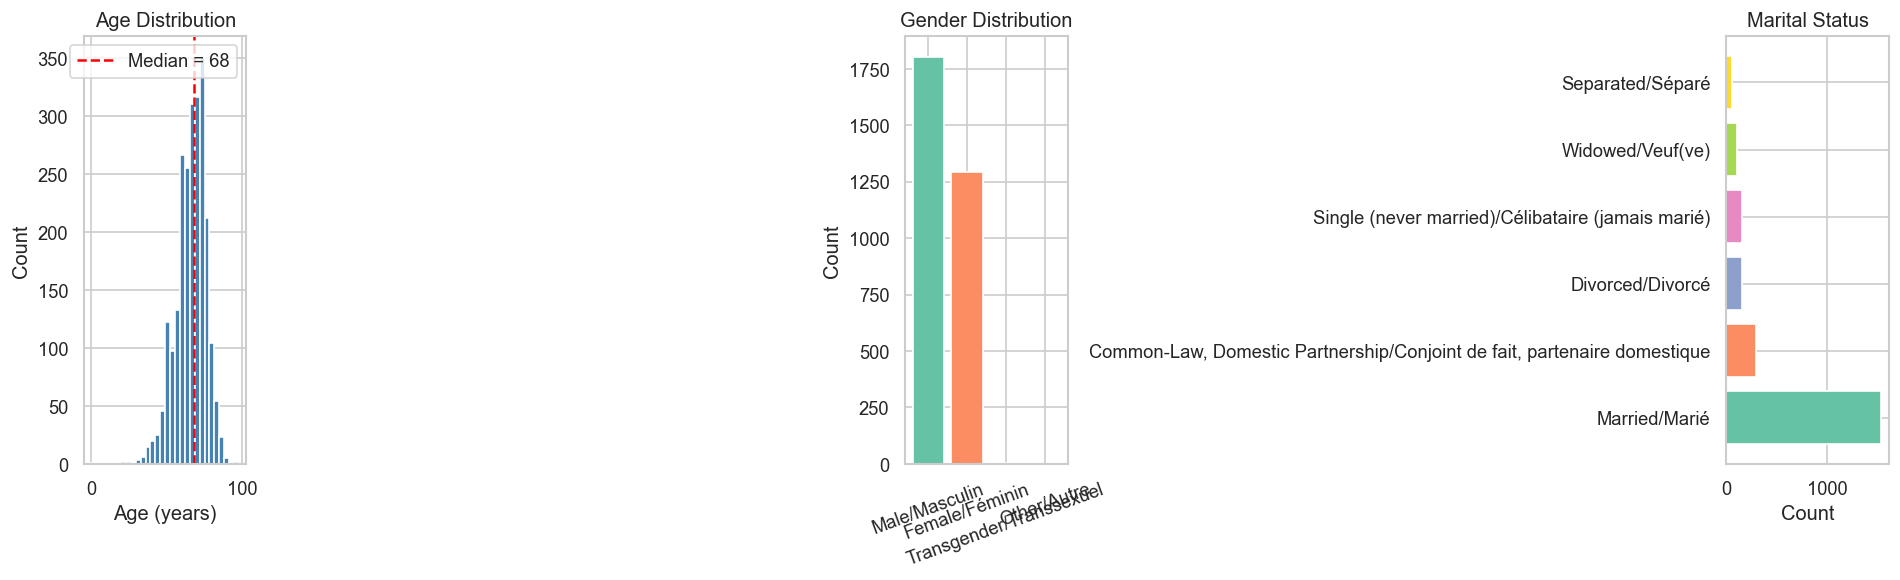

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Age distribution
axes[0].hist(demo['age'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(demo['age'].median(), color='red', linestyle='--', label=f"Median = {demo['age'].median():.0f}")
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Gender breakdown
gender_counts = demo[GENDER_COL].value_counts()
axes[1].bar(gender_counts.index, gender_counts.values,
            color=sns.color_palette('Set2', len(gender_counts)))
axes[1].set_title('Gender Distribution')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=20)

# Marital status
mar_counts = demo[MARITAL_COL].value_counts().head(6)
axes[2].barh(mar_counts.index, mar_counts.values,
             color=sns.color_palette('Set2', len(mar_counts)))
axes[2].set_title('Marital Status')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.show()

## 5. Clinical — Diagnosis Breakdown

The diagnosis codes map as follows:
- 0 = Parkinson's Disease (PD)
- 1 = Progressive Supranuclear Palsy (PSP)
- 2 = Multiple System Atrophy (MSA)
- 3 = Corticobasal Syndrome (CBS)
- 4 = Dementia with Lewy Bodies (DLB)
- 6 / 7 = Other / Not determined

In [7]:
DIAG_COL = [c for c in clin.columns if 'Determined diagnosis' in c][0]

DIAG_MAP = {
    0: 'PD',
    1: 'PSP',
    2: 'MSA',
    3: 'CBS',
    4: 'DLB',
    6: 'Other',
    7: 'Not determined'
}

clin['diagnosis_code'] = pd.to_numeric(clin[DIAG_COL], errors='coerce')
clin['diagnosis'] = clin['diagnosis_code'].map(DIAG_MAP).fillna('Unknown')

diag_counts = clin['diagnosis'].value_counts()
print('Diagnosis distribution:')
print(diag_counts.to_string())

Diagnosis distribution:
diagnosis
PD                2053
Unknown           1371
PSP                 35
MSA                 26
Not determined      21
Other               16
DLB                 10
CBS                  9


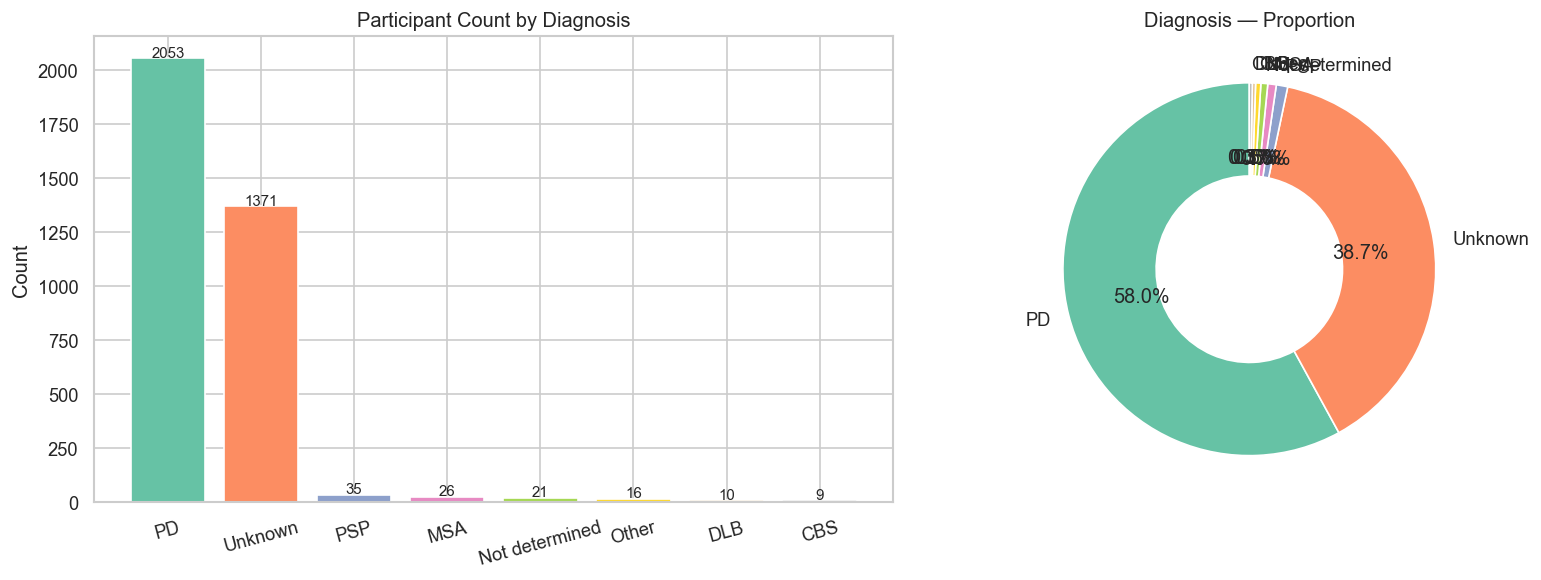

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = sns.color_palette('Set2', len(diag_counts))

# Bar chart
axes[0].bar(diag_counts.index, diag_counts.values, color=colors)
axes[0].set_title('Participant Count by Diagnosis')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(diag_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=9)

# Pie chart
wedge_props = dict(width=0.5)  # donut
axes[1].pie(diag_counts.values, labels=diag_counts.index,
            autopct='%1.1f%%', colors=colors,
            wedgeprops=wedge_props, startangle=90)
axes[1].set_title('Diagnosis — Proportion')

plt.tight_layout()
plt.show()

### 5a. Age by Diagnosis

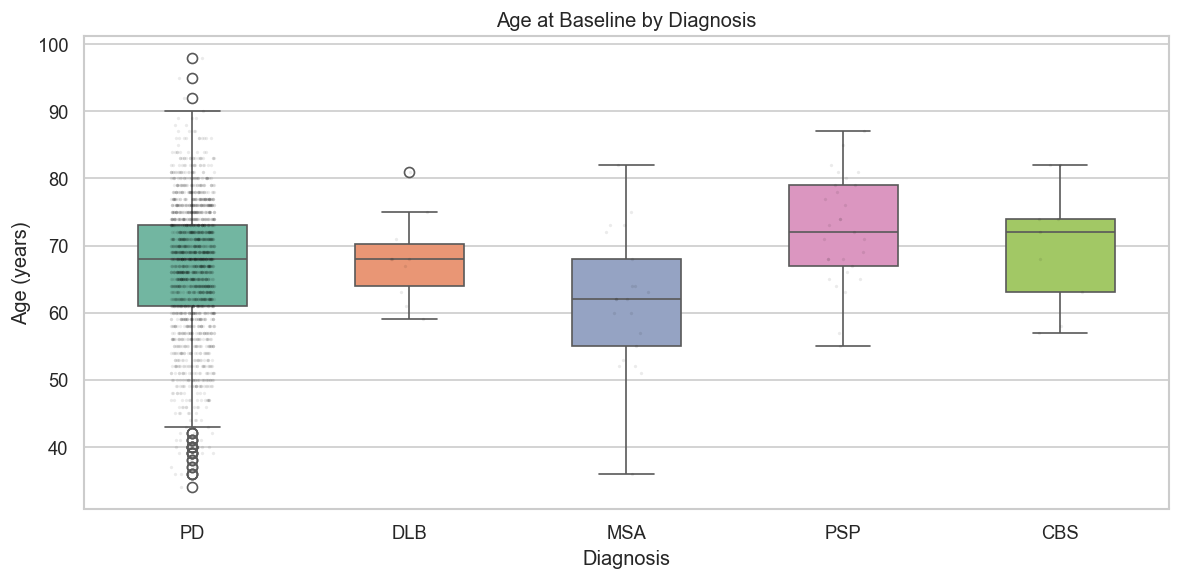

            count  mean   std   min   25%   50%   75%   max
diagnosis                                                  
CBS           9.0  70.0   9.3  57.0  63.0  72.0  74.0  82.0
DLB          10.0  68.1   6.5  59.0  64.0  68.0  70.2  81.0
MSA          21.0  61.7  10.3  36.0  55.0  62.0  68.0  82.0
PD         1921.0  66.6   9.4  34.0  61.0  68.0  73.0  98.0
PSP          29.0  72.2   8.0  55.0  67.0  72.0  79.0  87.0


In [9]:
# Merge age into clinical
clin_demo = clin[['Project key', 'diagnosis']].merge(
    demo[['Project key', 'age', GENDER_COL]],
    on='Project key', how='left'
)
clin_demo = clin_demo[clin_demo['diagnosis'].isin(['PD', 'PSP', 'MSA', 'CBS', 'DLB'])]

fig, ax = plt.subplots(figsize=(10, 5))
order = ['PD', 'DLB', 'MSA', 'PSP', 'CBS']
sns.boxplot(data=clin_demo, x='diagnosis', y='age', order=order,
            palette='Set2', ax=ax, width=0.5)
sns.stripplot(data=clin_demo, x='diagnosis', y='age', order=order,
              color='black', alpha=0.08, size=2, ax=ax)
ax.set_title('Age at Baseline by Diagnosis')
ax.set_xlabel('Diagnosis')
ax.set_ylabel('Age (years)')
plt.tight_layout()
plt.show()

print(clin_demo.groupby('diagnosis')['age'].describe().round(1))

## 6. Cognitive Assessment — MoCA

The Montreal Cognitive Assessment (MoCA) is scored out of 30. Score < 26 indicates mild cognitive impairment.

In [10]:
MOCA_TOTAL_COL  = [c for c in moca.columns if 'TOTAL SCORE' in c][0]
MOCA_SUB_COLS   = [
    c for c in moca.columns
    if any(s in c for s in ['Visuospatial', 'Naming Score', 'Memory Score',
                             'Attention Score', 'Language Score',
                             'Abstraction Score', 'Delayed Recall', 'Orientation Score'])
]

moca['moca_total'] = pd.to_numeric(moca[MOCA_TOTAL_COL], errors='coerce')
for col in MOCA_SUB_COLS:
    moca[col] = pd.to_numeric(moca[col], errors='coerce')

n_valid = moca['moca_total'].notna().sum()
print(f"MoCA total scores available: {n_valid} / {len(moca)}")
print(moca['moca_total'].describe().round(2))

MoCA total scores available: 2069 / 3541
count    2069.00
mean       25.17
std         4.80
min         0.00
25%        24.00
50%        26.00
75%        28.00
max        30.00
Name: moca_total, dtype: float64


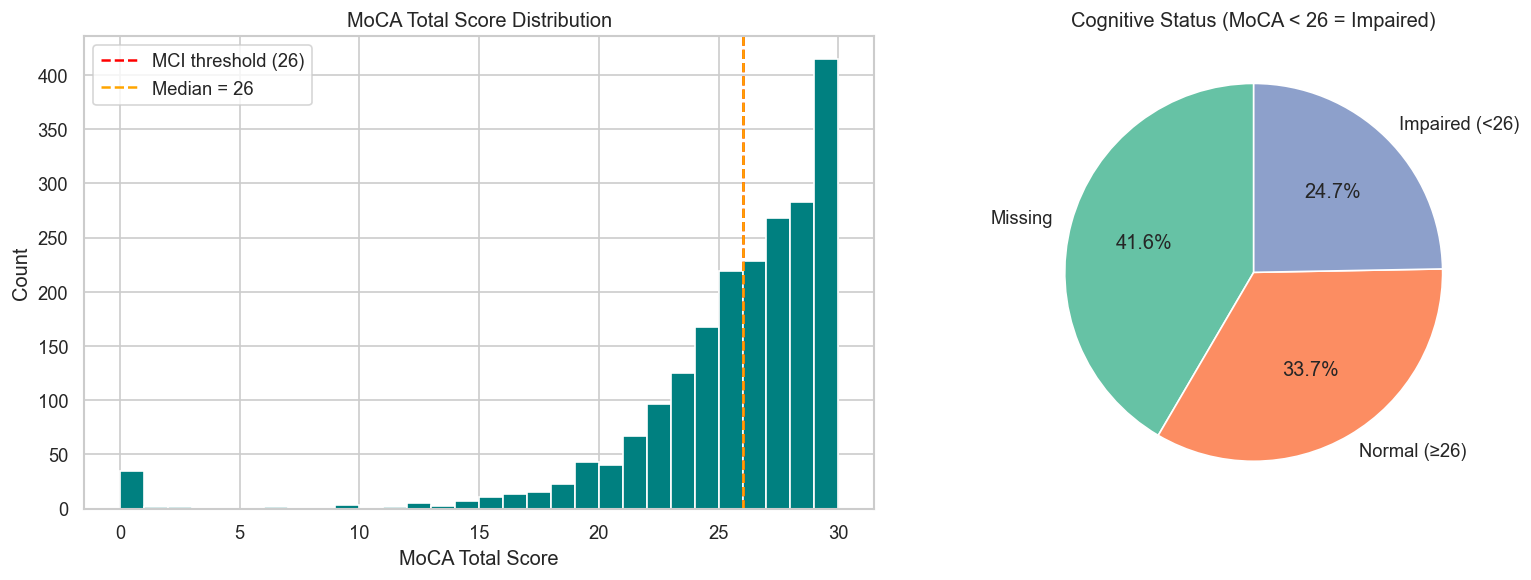

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall MoCA distribution
axes[0].hist(moca['moca_total'].dropna(), bins=30, color='teal', edgecolor='white')
axes[0].axvline(26, color='red', linestyle='--', linewidth=1.5, label='MCI threshold (26)')
axes[0].axvline(moca['moca_total'].median(), color='orange', linestyle='--',
                linewidth=1.5, label=f"Median = {moca['moca_total'].median():.0f}")
axes[0].set_title('MoCA Total Score Distribution')
axes[0].set_xlabel('MoCA Total Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# Proportion above/below MCI threshold
moca['cognitive_status'] = moca['moca_total'].apply(
    lambda x: 'Normal (≥26)' if x >= 26 else ('Impaired (<26)' if pd.notna(x) else 'Missing')
)
status_counts = moca['cognitive_status'].value_counts()
axes[1].pie(status_counts.values,
            labels=status_counts.index,
            autopct='%1.1f%%',
            colors=['#66c2a5', '#fc8d62', '#8da0cb'],
            startangle=90)
axes[1].set_title('Cognitive Status (MoCA < 26 = Impaired)')

plt.tight_layout()
plt.show()

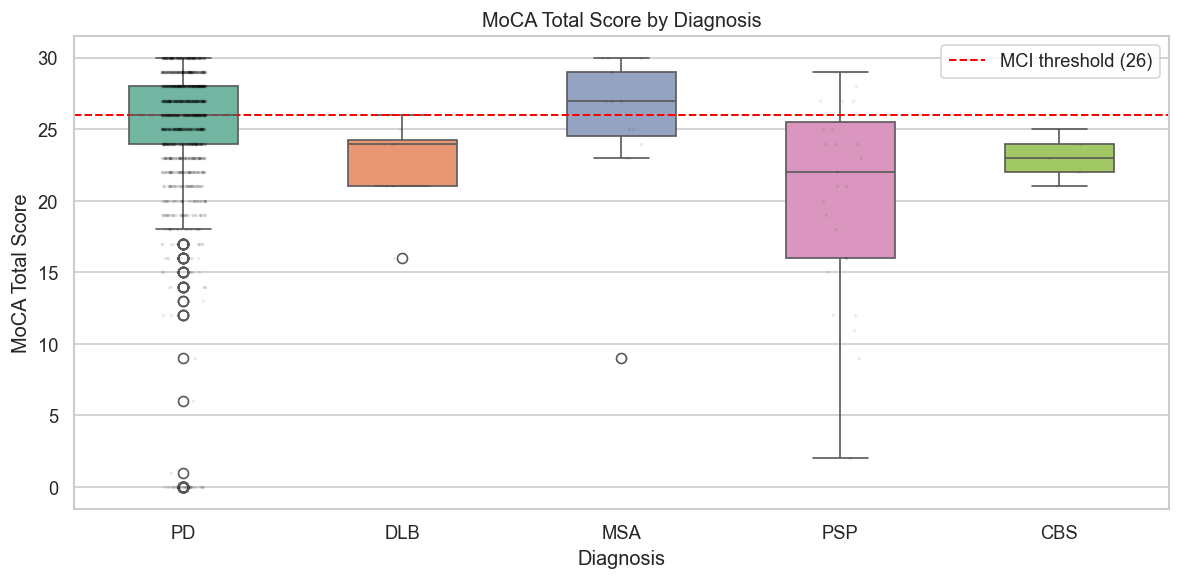

            count   mean   std   min   25%   50%    75%   max
diagnosis                                                    
CBS           5.0  23.00  1.58  21.0  22.0  23.0  24.00  25.0
DLB           8.0  22.62  3.20  16.0  21.0  24.0  24.25  26.0
MSA          15.0  25.67  5.22   9.0  24.5  27.0  29.00  30.0
PD         1610.0  24.99  5.06   0.0  24.0  26.0  28.00  30.0
PSP          27.0  20.44  6.89   2.0  16.0  22.0  25.50  29.0


In [12]:
# MoCA by diagnosis
moca_clin = moca[['Project key', 'moca_total']].merge(
    clin[['Project key', 'diagnosis']], on='Project key', how='left'
)
moca_clin = moca_clin[moca_clin['diagnosis'].isin(['PD', 'PSP', 'MSA', 'CBS', 'DLB'])]

fig, ax = plt.subplots(figsize=(10, 5))
order = ['PD', 'DLB', 'MSA', 'PSP', 'CBS']
sns.boxplot(data=moca_clin, x='diagnosis', y='moca_total', order=order,
            palette='Set2', ax=ax, width=0.5)
sns.stripplot(data=moca_clin, x='diagnosis', y='moca_total', order=order,
              color='black', alpha=0.08, size=2, ax=ax)
ax.axhline(26, color='red', linestyle='--', linewidth=1.2, label='MCI threshold (26)')
ax.set_title('MoCA Total Score by Diagnosis')
ax.set_xlabel('Diagnosis')
ax.set_ylabel('MoCA Total Score')
ax.legend()
plt.tight_layout()
plt.show()

print(moca_clin.groupby('diagnosis')['moca_total'].describe().round(2))

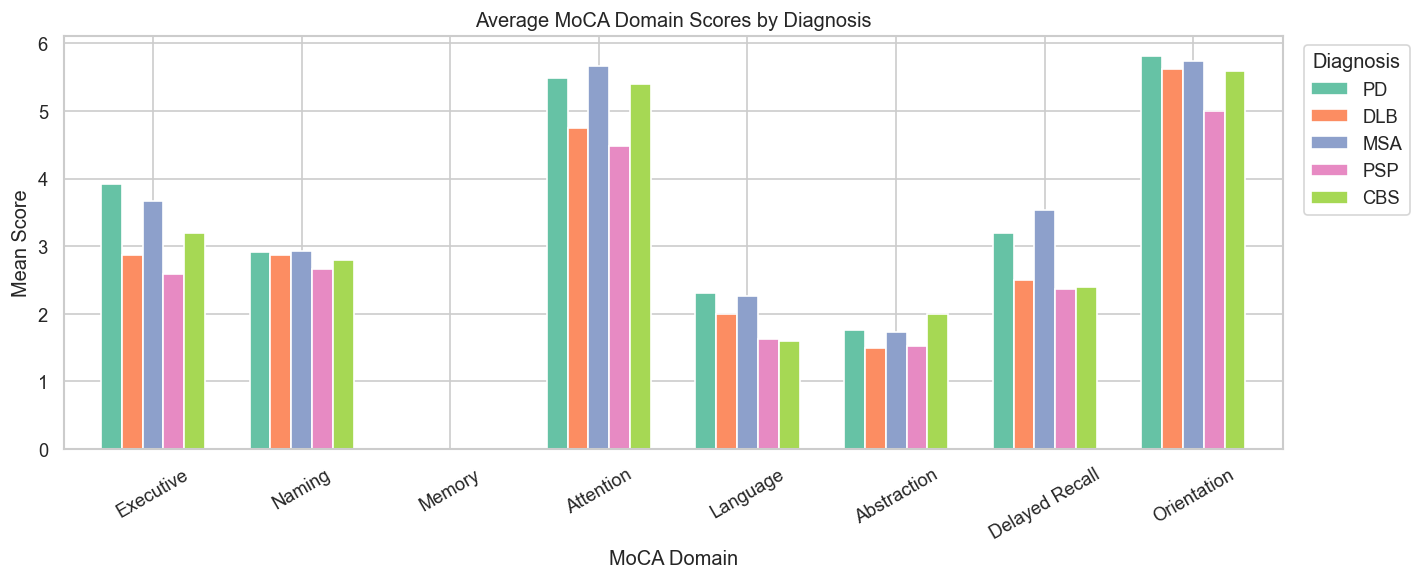

In [13]:
# MoCA domain subscores — average by diagnosis
DOMAIN_SHORT = {
    c: c.split('Score')[0].split('/')[-1].strip().replace('Visuospatial', 'Visuospatial/Exec')
    for c in MOCA_SUB_COLS
}

moca_sub = moca[['Project key'] + MOCA_SUB_COLS].merge(
    clin[['Project key', 'diagnosis']], on='Project key', how='left'
)
moca_sub = moca_sub[moca_sub['diagnosis'].isin(['PD', 'PSP', 'MSA', 'CBS', 'DLB'])]

domain_means = moca_sub.groupby('diagnosis')[MOCA_SUB_COLS].mean().rename(columns=DOMAIN_SHORT)
domain_means = domain_means.loc[['PD', 'DLB', 'MSA', 'PSP', 'CBS']]

fig, ax = plt.subplots(figsize=(12, 5))
domain_means.T.plot(kind='bar', ax=ax, width=0.7,
                    color=sns.color_palette('Set2', 5))
ax.set_title('Average MoCA Domain Scores by Diagnosis')
ax.set_xlabel('MoCA Domain')
ax.set_ylabel('Mean Score')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Diagnosis', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 7. Motor Assessment — MDS-UPDRS

The MDS-UPDRS has four parts:
- **Part I** — Non-Motor Aspects of Daily Living
- **Part II** — Motor Aspects of Daily Living
- **Part III** — Motor Examination (clinician-rated)
- **Part IV** — Motor Complications

In [14]:
UPDRS_PARTS = {
    'Part I (Non-Motor ADL)' : [c for c in updrs.columns if 'Part I:'  in c][0],
    'Part II (Motor ADL)'    : [c for c in updrs.columns if 'Part II:' in c][0],
    'Part III (Motor Exam)'  : [c for c in updrs.columns if 'Part III:' in c][0],
    'Part IV (Complications)': [c for c in updrs.columns if 'Part IV:' in c][0],
}

for short, col in UPDRS_PARTS.items():
    updrs[short] = pd.to_numeric(updrs[col], errors='coerce')

updrs['updrs_total'] = updrs[list(UPDRS_PARTS.keys())].sum(axis=1, min_count=1)

print('MDS-UPDRS part summaries:')
print(updrs[list(UPDRS_PARTS.keys()) + ['updrs_total']].describe().round(2))

MDS-UPDRS part summaries:
       Part I (Non-Motor ADL)  Part II (Motor ADL)  Part III (Motor Exam)  \
count                 1542.00              1541.00                1784.00   
mean                    10.35                10.56                  28.26   
std                      6.35                 7.88                  15.88   
min                      0.00                 0.00                   0.00   
25%                      6.00                 5.00                  16.00   
50%                      9.00                 9.00                  26.00   
75%                     14.00                15.00                  38.00   
max                     44.00                41.00                  96.00   

       Part IV (Complications)  updrs_total  
count                  1537.00      1825.00  
mean                      3.76        48.45  
std                       3.73        27.56  
min                       0.00         0.00  
25%                       0.00        27.00  
50% 

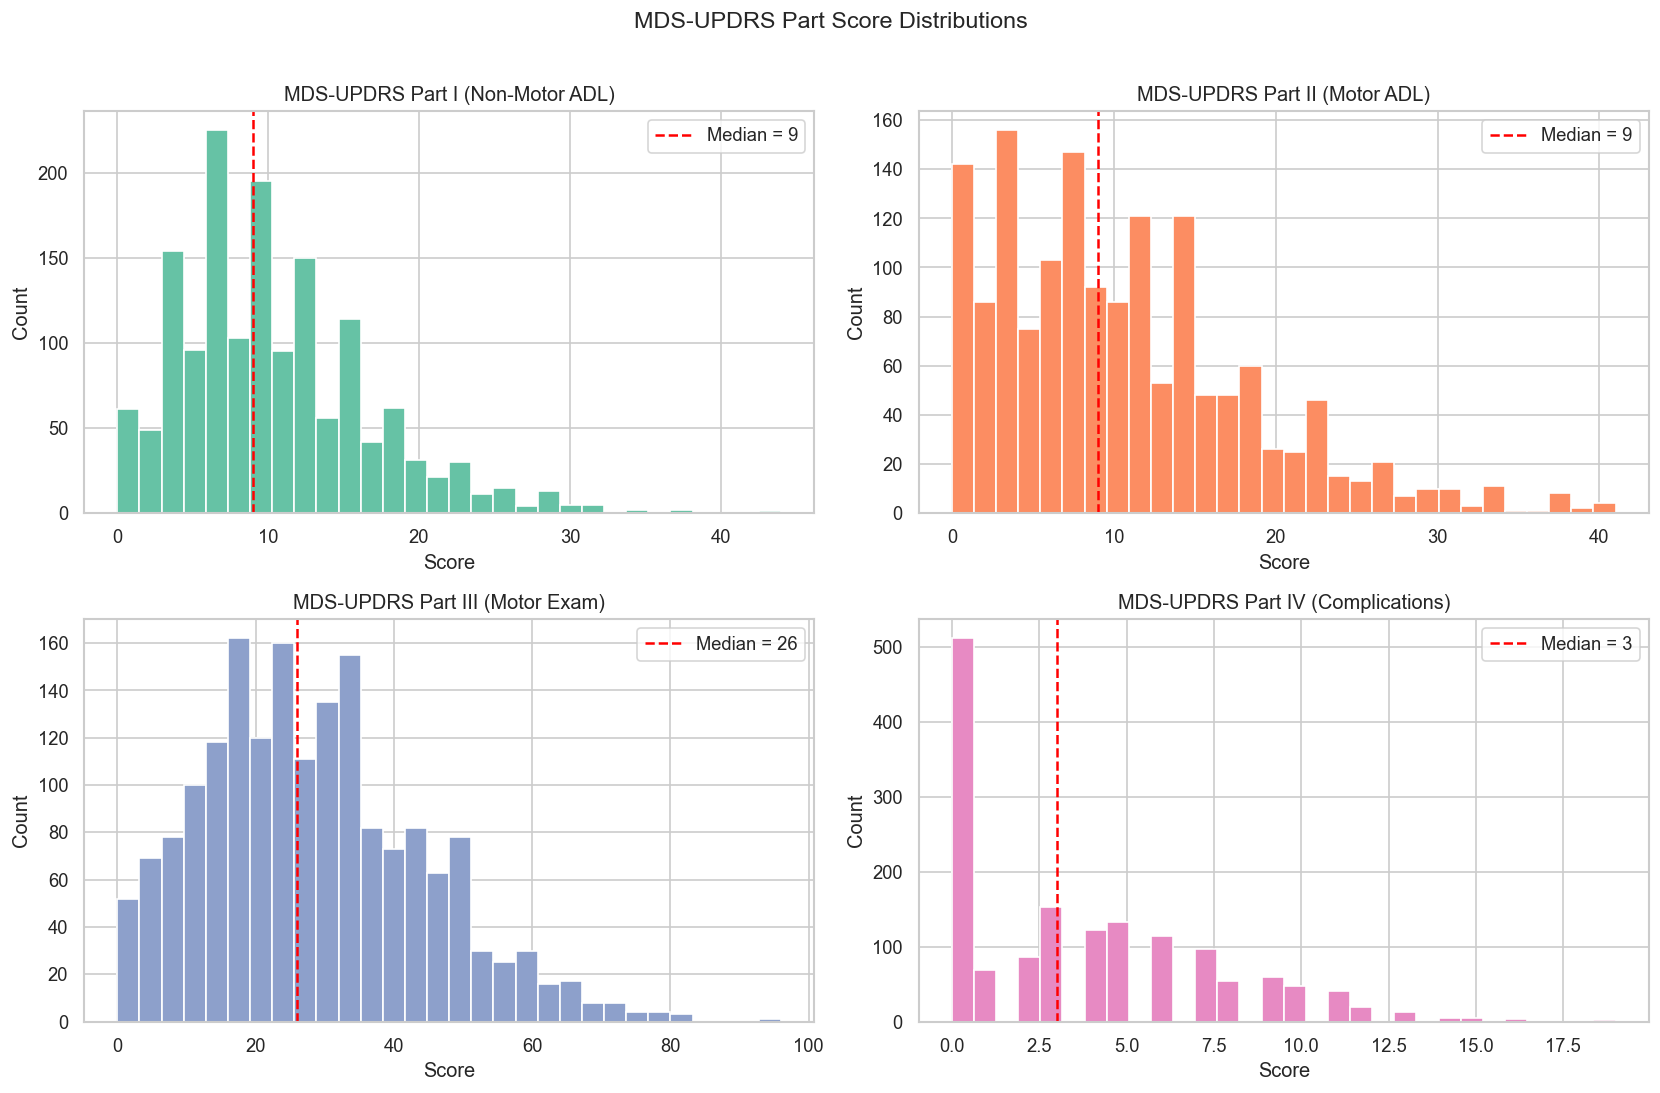

In [15]:
# Distribution of UPDRS part scores
part_cols = list(UPDRS_PARTS.keys())

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
colors = sns.color_palette('Set2', 4)

for i, (part, col) in enumerate(zip(part_cols, colors)):
    data = updrs[part].dropna()
    axes[i].hist(data, bins=30, color=col, edgecolor='white')
    axes[i].axvline(data.median(), color='red', linestyle='--',
                    label=f'Median = {data.median():.0f}')
    axes[i].set_title(f'MDS-UPDRS {part}')
    axes[i].set_xlabel('Score')
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.suptitle('MDS-UPDRS Part Score Distributions', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

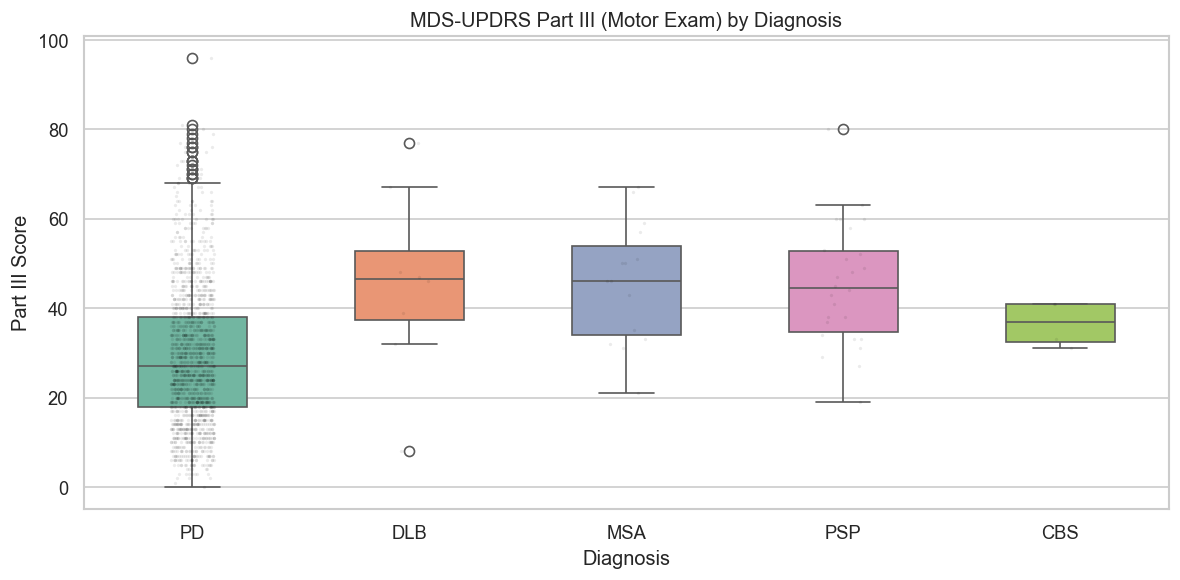

            count   mean    std   min    25%   50%    75%   max
diagnosis                                                      
CBS           4.0  36.50   5.26  31.0  32.50  37.0  41.00  41.0
DLB           8.0  45.50  21.02   8.0  37.25  46.5  52.75  77.0
MSA          15.0  45.80  13.45  21.0  34.00  46.0  54.00  67.0
PD         1553.0  28.84  15.04   0.0  18.00  27.0  38.00  96.0
PSP          26.0  45.12  13.59  19.0  34.75  44.5  52.75  80.0


In [16]:
# UPDRS Part III by diagnosis
updrs_clin = updrs[['Project key'] + part_cols + ['updrs_total']].merge(
    clin[['Project key', 'diagnosis']], on='Project key', how='left'
)
updrs_clin = updrs_clin[updrs_clin['diagnosis'].isin(['PD', 'PSP', 'MSA', 'CBS', 'DLB'])]

fig, ax = plt.subplots(figsize=(10, 5))
order = ['PD', 'DLB', 'MSA', 'PSP', 'CBS']
sns.boxplot(data=updrs_clin, x='diagnosis', y='Part III (Motor Exam)',
            order=order, palette='Set2', ax=ax, width=0.5)
sns.stripplot(data=updrs_clin, x='diagnosis', y='Part III (Motor Exam)',
              order=order, color='black', alpha=0.08, size=2, ax=ax)
ax.set_title('MDS-UPDRS Part III (Motor Exam) by Diagnosis')
ax.set_xlabel('Diagnosis')
ax.set_ylabel('Part III Score')
plt.tight_layout()
plt.show()

print(updrs_clin.groupby('diagnosis')['Part III (Motor Exam)'].describe().round(2))

## 8. Cognitive–Motor Correlation

Explore the relationship between MoCA total score and MDS-UPDRS Part III motor score.

In [17]:
combined = moca[['Project key', 'moca_total']].merge(
    updrs[['Project key', 'Part III (Motor Exam)', 'updrs_total']],
    on='Project key', how='inner'
).merge(
    clin[['Project key', 'diagnosis']], on='Project key', how='left'
).merge(
    demo[['Project key', 'age']], on='Project key', how='left'
)

combined = combined[combined['diagnosis'].isin(['PD', 'PSP', 'MSA', 'CBS', 'DLB'])]
combined = combined.dropna(subset=['moca_total', 'Part III (Motor Exam)'])

print(f'Combined dataset for correlation: {len(combined)} participants')

r = combined['moca_total'].corr(combined['Part III (Motor Exam)'])
print(f"Pearson r (MoCA vs UPDRS-III): {r:.3f}")

Combined dataset for correlation: 1534 participants
Pearson r (MoCA vs UPDRS-III): -0.182


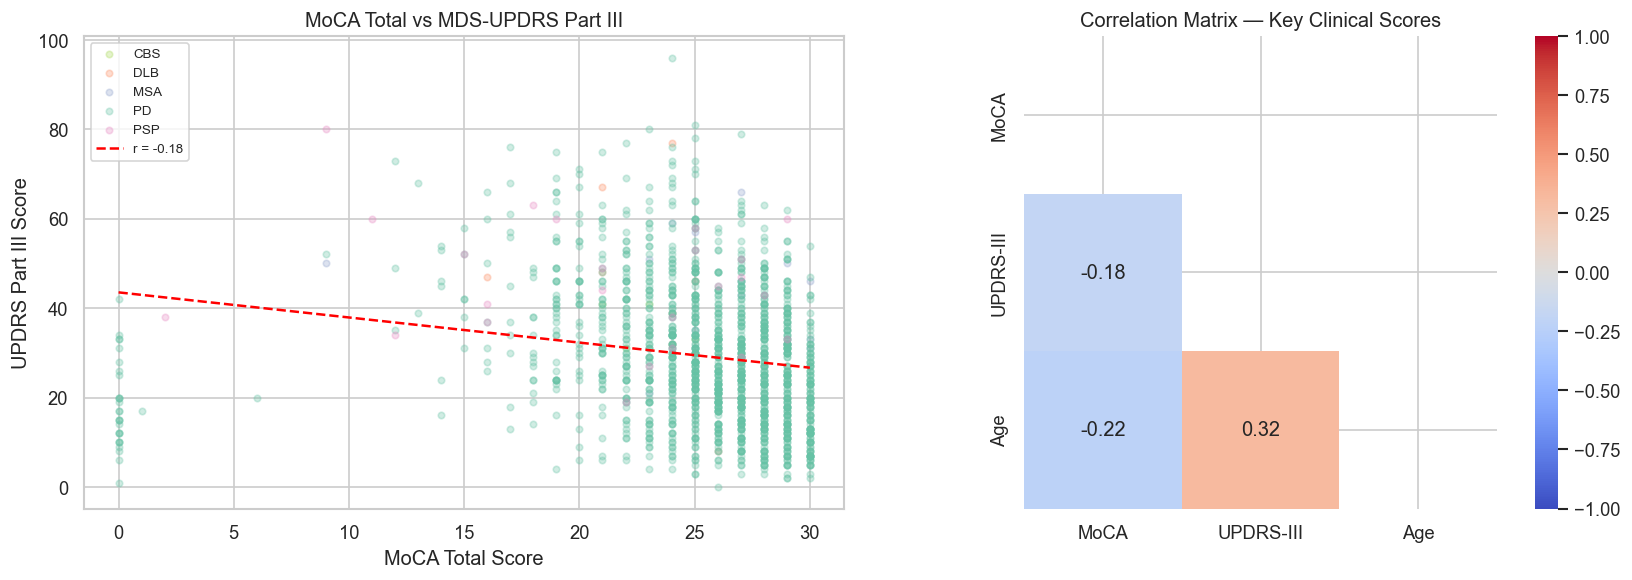

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: MoCA vs UPDRS-III, colored by diagnosis
diag_palette = {'PD': '#66c2a5', 'DLB': '#fc8d62', 'MSA': '#8da0cb',
                'PSP': '#e78ac3', 'CBS': '#a6d854'}
for diag, grp in combined.groupby('diagnosis'):
    axes[0].scatter(grp['moca_total'], grp['Part III (Motor Exam)'],
                    alpha=0.3, s=15, label=diag, color=diag_palette.get(diag, 'gray'))

# Regression line
from numpy.polynomial import polynomial as P
x_clean = combined['moca_total'].dropna()
y_clean = combined.loc[x_clean.index, 'Part III (Motor Exam)'].dropna()
idx = x_clean.index.intersection(y_clean.index)
coefs = np.polyfit(x_clean[idx], y_clean[idx], 1)
xline = np.linspace(x_clean[idx].min(), x_clean[idx].max(), 100)
axes[0].plot(xline, np.polyval(coefs, xline), 'r--', linewidth=1.5, label=f'r = {r:.2f}')
axes[0].set_title('MoCA Total vs MDS-UPDRS Part III')
axes[0].set_xlabel('MoCA Total Score')
axes[0].set_ylabel('UPDRS Part III Score')
axes[0].legend(fontsize=8)

# Heatmap: correlation matrix of key scores
corr_cols = {
    'MoCA': 'moca_total',
    'UPDRS-I': 'Part I (Non-Motor ADL)',
    'UPDRS-II': 'Part II (Motor ADL)',
    'UPDRS-III': 'Part III (Motor Exam)',
    'UPDRS-IV': 'Part IV (Complications)',
    'Age': 'age',
}
corr_df = combined[[v for v in corr_cols.values() if v in combined.columns]].copy()
corr_df.columns = [k for k, v in corr_cols.items() if v in combined.columns]
corr_matrix = corr_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=axes[1], square=True)
axes[1].set_title('Correlation Matrix — Key Clinical Scores')

plt.tight_layout()
plt.show()

## 9. Enrollment Site Distribution

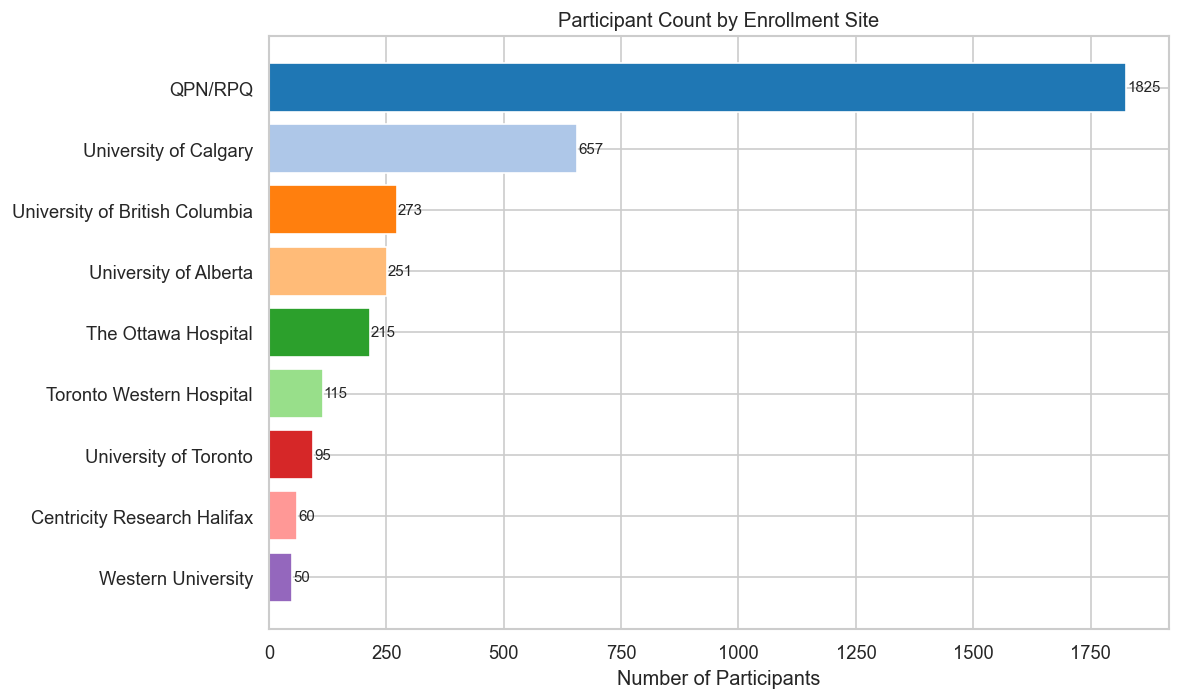

In [19]:
SITE_COL = [c for c in enroll.columns if c.strip() == 'Site:'][0]

site_counts = enroll[SITE_COL].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette('tab20', len(site_counts))
bars = ax.barh(site_counts.index[::-1], site_counts.values[::-1], color=colors[::-1])
ax.set_title('Participant Count by Enrollment Site')
ax.set_xlabel('Number of Participants')
for bar, val in zip(bars, site_counts.values[::-1]):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 10. Summary

| Metric | Value |
|--------|-------|
| Total participants | 3,541 |
| Primary diagnosis | PD (majority) |
| Datasets loaded | 30 files |
| Join key | `Project key` |
| Visit type | Baseline only |

**Next steps you might explore:**
- Medication analysis (levodopa dose, drug classes)
- Fatigue, apathy, and depression scales (BAI, Apathy Scale, FSS)
- Neuropsychological battery breakdown
- PDQ-39 quality of life analysis
- Hoehn & Yahr staging vs UPDRS-III